In [67]:
# Cell 1
# =============================================================================
# Load Augmented DataFrames (Nodes A–H) & Base Label Encoder
# =============================================================================

import os
import joblib
import pandas as pd

NODES = ["A", "B", "C", "D", "E", "F", "G", "H"]
AUG_DIR = "dataset/normalized/augmented"
MODEL_DIR = "models"

aug_train = {}
aug_test = {}

# Load precomputed node-level augmented datasets
for node in NODES:
    aug_train[node] = joblib.load(os.path.join(AUG_DIR, f"Node_{node}_aug_train.pkl"))
    aug_test[node]  = joblib.load(os.path.join(AUG_DIR, f"Node_{node}_aug_test.pkl"))

# Load baseline label encoder
le = joblib.load(os.path.join(MODEL_DIR, "label_encoder.joblib"))

print(f"Loaded augmented node datasets from: '{AUG_DIR}'")
print(f"Baseline classes: {le.classes_}")
print(f"Example augmented columns (Node A): {aug_train['A'].columns.tolist()}")

Loaded augmented node datasets from: 'dataset/normalized/augmented'
Baseline classes: ['Backdoor' 'none' 'syn-flood']
Example augmented columns (Node A): ['shunt_voltage', 'bus_voltage_V', 'current_mA', 'power_mW', 'State', 'Attack', 'data_source', 'prob_Backdoor', 'prob_none', 'prob_syn-flood', 'agg_shunt_voltage', 'agg_bus_voltage_V', 'agg_current_mA', 'agg_power_mW', 'agg_prob_Backdoor', 'agg_prob_none', 'agg_prob_syn-flood', 'agg_weight_sum', 'agg_num_contributors']


In [68]:
# Cell 2
# =============================================================================
# Prepare Augmented Data & Define Feature Sets Per Node (No State Features)
# =============================================================================

import pandas as pd

print("=== Node-Level Augmented Dataset Shapes ===")
for node in NODES:
    print(
        f"Node {node}: "
        f"Train Shape = {aug_train[node].shape}, "
        f"Test Shape = {aug_test[node].shape}"
    )

# -----------------------------------------------------------------------------
# Define Feature Sets (Hardware Sensor Metrics & Probability Contexts Only)
# -----------------------------------------------------------------------------
original_numeric = [
    "shunt_voltage",
    "bus_voltage_V",
    "current_mA",
    "power_mW"
]

own_prob_cols = [
    f"prob_{cls_name}"
    for cls_name in le.classes_
]

agg_numeric = [
    f"agg_{feature}"
    for feature in original_numeric
]

agg_prob_cols = [
    f"agg_prob_{cls_name}"
    for cls_name in le.classes_
]

# Model 1: Own hardware + aggregated context (No State)
feature_cols_hw_plus_agg = (
    original_numeric
    + agg_numeric
    + agg_prob_cols
)

# Model 2: Full context (No State)
feature_cols_full = (
    original_numeric
    + own_prob_cols
    + agg_numeric
    + agg_prob_cols
)

print(
    f"\nModel 1 Feature Count "
    f"(Own HW + Agg Context): {len(feature_cols_hw_plus_agg)}"
)
print(f"Features: {feature_cols_hw_plus_agg}")

print(
    f"\nModel 2 Feature Count "
    f"(Full Context): {len(feature_cols_full)}"
)
print(f"Features: {feature_cols_full}")

=== Node-Level Augmented Dataset Shapes ===
Node A: Train Shape = (50826, 19), Test Shape = (21801, 19)
Node B: Train Shape = (50826, 19), Test Shape = (21801, 19)
Node C: Train Shape = (50826, 19), Test Shape = (21801, 19)
Node D: Train Shape = (50826, 19), Test Shape = (21801, 19)
Node E: Train Shape = (50826, 19), Test Shape = (21801, 19)
Node F: Train Shape = (50826, 19), Test Shape = (21801, 19)
Node G: Train Shape = (50826, 19), Test Shape = (21801, 19)
Node H: Train Shape = (50826, 19), Test Shape = (21801, 19)

Model 1 Feature Count (Own HW + Agg Context): 11
Features: ['shunt_voltage', 'bus_voltage_V', 'current_mA', 'power_mW', 'agg_shunt_voltage', 'agg_bus_voltage_V', 'agg_current_mA', 'agg_power_mW', 'agg_prob_Backdoor', 'agg_prob_none', 'agg_prob_syn-flood']

Model 2 Feature Count (Full Context): 14
Features: ['shunt_voltage', 'bus_voltage_V', 'current_mA', 'power_mW', 'prob_Backdoor', 'prob_none', 'prob_syn-flood', 'agg_shunt_voltage', 'agg_bus_voltage_V', 'agg_current_mA'

In [69]:
# Cell 3
# =============================================================================
# Export Node-Specific Augmented Datasets to CSV
# =============================================================================

import os

CSV_OUTPUT_DIR = "dataset/normalized/augmented_csv"
os.makedirs(CSV_OUTPUT_DIR, exist_ok=True)

for node in NODES:
    train_csv_path = os.path.join(
        CSV_OUTPUT_DIR,
        f"Node_{node}_combined_augmented_train.csv"
    )

    test_csv_path = os.path.join(
        CSV_OUTPUT_DIR,
        f"Node_{node}_combined_augmented_test.csv"
    )

    aug_train[node].to_csv(
        train_csv_path,
        index=False
    )

    aug_test[node].to_csv(
        test_csv_path,
        index=False
    )

    print(f"Saved Node {node} CSV files:")
    print(
        f"  - Train: {train_csv_path} "
        f"(Shape: {aug_train[node].shape})"
    )
    print(
        f"  - Test:  {test_csv_path} "
        f"(Shape: {aug_test[node].shape})"
    )

Saved Node A CSV files:
  - Train: dataset/normalized/augmented_csv/Node_A_combined_augmented_train.csv (Shape: (50826, 19))
  - Test:  dataset/normalized/augmented_csv/Node_A_combined_augmented_test.csv (Shape: (21801, 19))
Saved Node B CSV files:
  - Train: dataset/normalized/augmented_csv/Node_B_combined_augmented_train.csv (Shape: (50826, 19))
  - Test:  dataset/normalized/augmented_csv/Node_B_combined_augmented_test.csv (Shape: (21801, 19))
Saved Node C CSV files:
  - Train: dataset/normalized/augmented_csv/Node_C_combined_augmented_train.csv (Shape: (50826, 19))
  - Test:  dataset/normalized/augmented_csv/Node_C_combined_augmented_test.csv (Shape: (21801, 19))
Saved Node D CSV files:
  - Train: dataset/normalized/augmented_csv/Node_D_combined_augmented_train.csv (Shape: (50826, 19))
  - Test:  dataset/normalized/augmented_csv/Node_D_combined_augmented_test.csv (Shape: (21801, 19))
Saved Node E CSV files:
  - Train: dataset/normalized/augmented_csv/Node_E_combined_augmented_train.

=== Model 1 (2:1 Weighted): Node A (Samples: 21801) ===
  OOB Score:             0.933459
  Macro F1-Score:        0.859178
  Mean Squared Error:    0.183203
  Log Loss:              0.602299
  ROC-AUC Score:         0.957813
  Confusion Matrix (Rows: True, Cols: Predicted):
  Classes: ['Backdoor' 'none' 'syn-flood']
  [[4909, 1145, 30], [1597, 8020, 16], [249, 120, 5715]]

=== Model 1 (2:1 Weighted): Node B (Samples: 21801) ===
  OOB Score:             0.957050
  Macro F1-Score:        0.874704
  Mean Squared Error:    0.155589
  Log Loss:              0.594545
  ROC-AUC Score:         0.965833
  Confusion Matrix (Rows: True, Cols: Predicted):
  Classes: ['Backdoor' 'none' 'syn-flood']
  [[4668, 892, 17], [1628, 9006, 13], [184, 55, 5338]]

=== Model 1 (2:1 Weighted): Node C (Samples: 21801) ===
  OOB Score:             0.967261
  Macro F1-Score:        0.915436
  Mean Squared Error:    0.096693
  Log Loss:              0.536573
  ROC-AUC Score:         0.972414
  Confusion Matrix (Ro

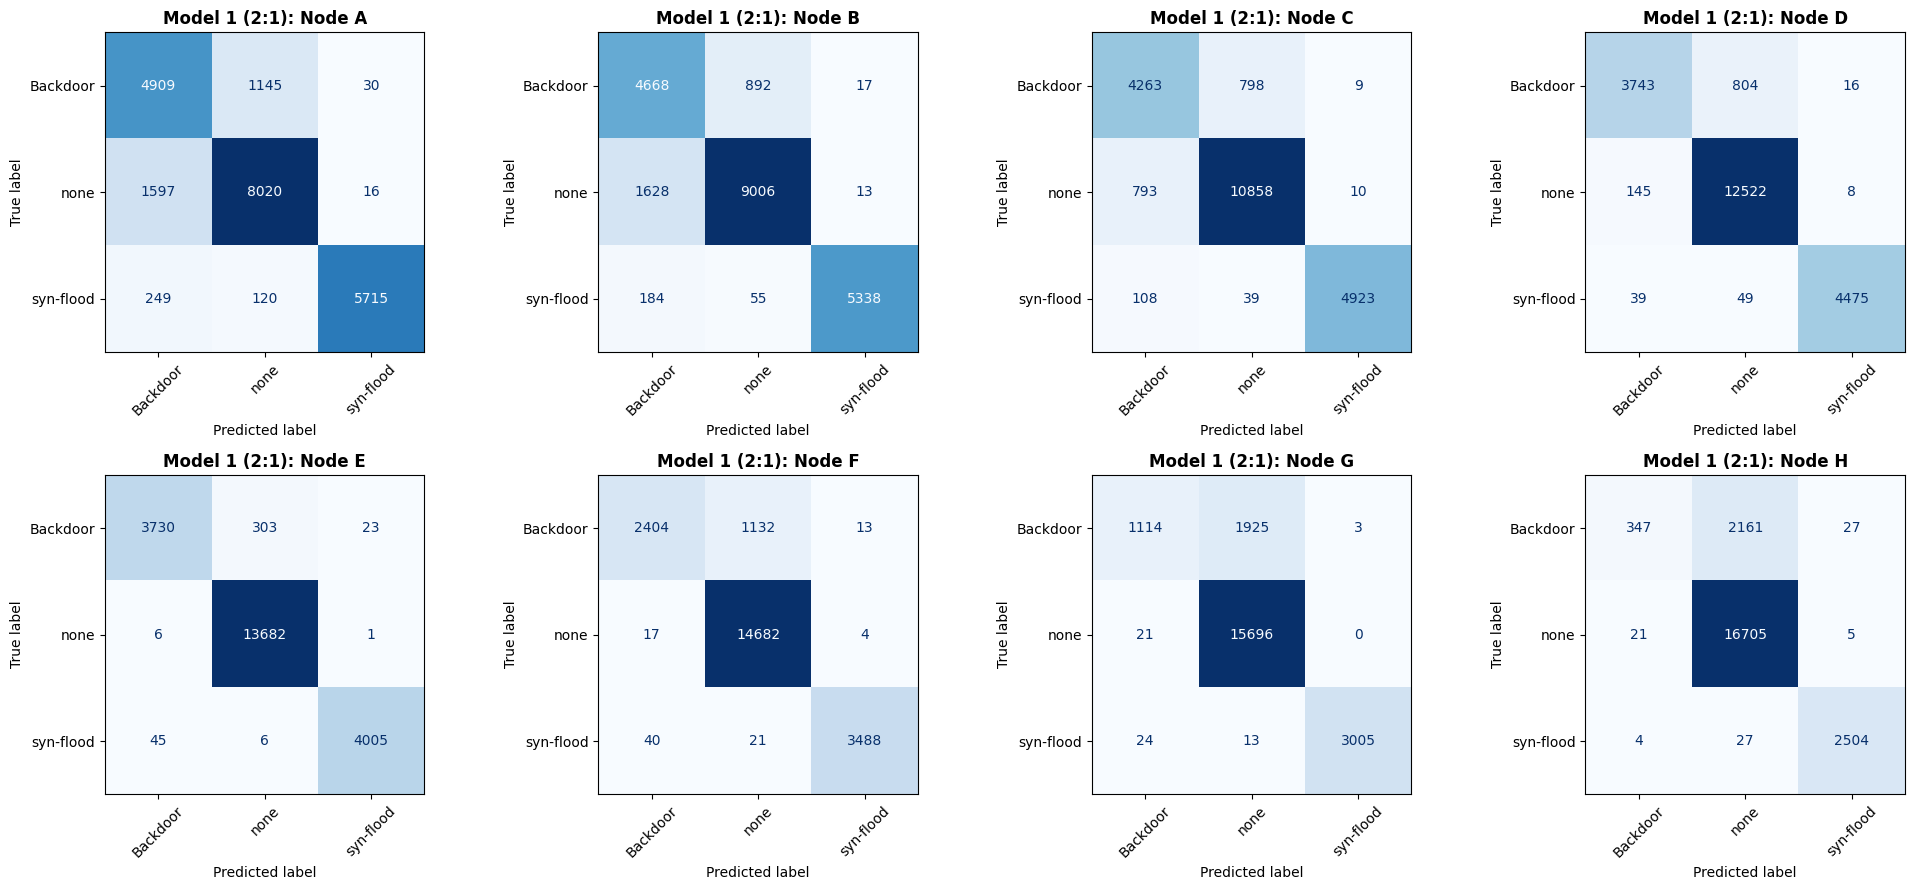

In [70]:
# Cell 6
# =============================================================================
# Model 1: Own HW (Weight 2) + Agg Context (Weight 1) [NO STATE]
# =============================================================================

import os
import joblib
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    ConfusionMatrixDisplay,
    accuracy_score,
    confusion_matrix,
    f1_score,
    log_loss,
    mean_squared_error,
    roc_auc_score,
)
from sklearn.preprocessing import StandardScaler

MODELS_DIR = "models"
os.makedirs(MODELS_DIR, exist_ok=True)

metrics_records_m1 = []
cm_dict_m1 = {}
classes_dict_m1 = {}
all_classes = le.classes_
num_classes = len(all_classes)
labels_arr = np.arange(num_classes)

# Containers to aggregate all node predictions for exact global metrics
all_y_true = []
all_y_pred = []
all_prob_m1 = []

for node in NODES:
    train_df = aug_train[node].copy()
    test_df = aug_test[node].copy()

    # Use global label encoder for uniform class mapping
    y_train = le.transform(train_df["Attack"])
    y_test = le.transform(test_df["Attack"])
    classes_dict_m1[node] = all_classes

    # -------------------------------------------------------------------------
    # 1. Separate Own vs. Aggregated Features & Enforce 2:1 Duplication
    # -------------------------------------------------------------------------
    own_cols = [c for c in feature_cols_hw_plus_agg if not c.startswith("agg_")]
    agg_cols = [c for c in feature_cols_hw_plus_agg if c.startswith("agg_")]

    X_train = train_df[feature_cols_hw_plus_agg].copy()
    X_test  = test_df[feature_cols_hw_plus_agg].copy()

    # Duplicate own hardware sensor features
    for col in own_cols:
        X_train[f"{col}_w2"] = X_train[col]
        X_test[f"{col}_w2"]  = X_test[col]

    # Standardize numeric columns
    numeric_own = [c for c in own_cols if c in original_numeric]
    numeric_all = numeric_own + [f"{c}_w2" for c in numeric_own] + agg_numeric

    scaler_w1 = StandardScaler()
    X_train[numeric_all] = scaler_w1.fit_transform(X_train[numeric_all])
    X_test[numeric_all]  = scaler_w1.transform(X_test[numeric_all])

    # -------------------------------------------------------------------------
    # 2. Train Random Forest Classifier
    # -------------------------------------------------------------------------
    rf_w1 = RandomForestClassifier(
        n_estimators=100,
        random_state=42,
        oob_score=True,
        n_jobs=-1
    )
    rf_w1.fit(X_train.to_numpy(), y_train)

    prob_m1 = rf_w1.predict_proba(X_test.to_numpy())
    pred_m1 = np.argmax(prob_m1, axis=1)

    # Accumulate arrays for global benchmarking
    all_y_true.append(y_test)
    all_y_pred.append(pred_m1)
    all_prob_m1.append(prob_m1)

    # -------------------------------------------------------------------------
    # 3. Compute Per-Node Metrics
    # -------------------------------------------------------------------------
    macro_f1 = f1_score(y_test, pred_m1, average="macro")
    mse_error = mean_squared_error(y_test, pred_m1)
    loss = log_loss(y_test, prob_m1, labels=labels_arr)

    try:
        roc_auc = roc_auc_score(
            y_test,
            prob_m1,
            multi_class="ovr",
            average="macro",
            labels=labels_arr,
        )
    except ValueError:
        roc_auc = np.nan

    cm = confusion_matrix(y_test, pred_m1, labels=labels_arr)
    cm_dict_m1[node] = cm

    metrics_records_m1.append({
        "Node": f"Node {node}",
        "Samples": len(test_df),
        "Macro F1": macro_f1,
        "MSE": mse_error,
        "Log Loss": loss,
        "ROC-AUC": roc_auc,
    })

    print(f"=== Model 1 (2:1 Weighted): Node {node} (Samples: {len(test_df)}) ===")
    print(f"  OOB Score:             {rf_w1.oob_score_:.6f}")
    print(f"  Macro F1-Score:        {macro_f1:.6f}")
    print(f"  Mean Squared Error:    {mse_error:.6f}")
    print(f"  Log Loss:              {loss:.6f}")
    print(f"  ROC-AUC Score:         {roc_auc:.6f}")
    print("  Confusion Matrix (Rows: True, Cols: Predicted):")
    print(f"  Classes: {all_classes}")
    print(f"  {cm.tolist()}\n")

    # -------------------------------------------------------------------------
    # 4. Save Artifacts & Predictions
    # -------------------------------------------------------------------------
    model_path = os.path.join(MODELS_DIR, f"Node_{node}_rf_context_own_hw_plus_agg_w2.joblib")
    scaler_path = os.path.join(MODELS_DIR, f"Node_{node}_scaler_context_own_hw_plus_agg_w2.joblib")
    encoder_path = os.path.join(MODELS_DIR, f"Node_{node}_label_encoder_context_w2.joblib")
    feature_list_path = os.path.join(MODELS_DIR, f"Node_{node}_feature_list_own_hw_plus_agg_w2.csv")
    predictions_path = os.path.join(MODELS_DIR, f"Node_{node}_predictions_test_rf_context_own_hw_plus_agg_w2.csv")

    joblib.dump(rf_w1, model_path)
    joblib.dump(scaler_w1, scaler_path)
    joblib.dump(le, encoder_path)
    pd.DataFrame({"feature": X_train.columns.tolist()}).to_csv(feature_list_path, index=False)

    df_pred = test_df[["Attack"]].copy()
    df_pred["prediction"] = le.inverse_transform(pred_m1)
    for idx, cls_idx in enumerate(rf_w1.classes_):
        cls_name = le.inverse_transform([cls_idx])[0]
        df_pred[f"prob_{cls_name}"] = prob_m1[:, idx]
    df_pred.to_csv(predictions_path, index=False)

# =============================================================================
# Summary DataFrame and Exact Global Metrics Across All Pooled Nodes
# =============================================================================
df_summary_m1 = pd.DataFrame(metrics_records_m1)
print("=============================================================================")
print("PER-NODE SUMMARY (MODEL 1 - NO STATE, 2:1 WEIGHTED):")
print(df_summary_m1.to_string(index=False))

# Concatenate all true labels, predicted classes, and probabilities
y_true_all = np.concatenate(all_y_true)
y_pred_all = np.concatenate(all_y_pred)
y_prob_all = np.concatenate(all_prob_m1, axis=0)

global_acc = accuracy_score(y_true_all, y_pred_all)
global_macro_f1 = f1_score(y_true_all, y_pred_all, average="macro")
global_weighted_f1 = f1_score(y_true_all, y_pred_all, average="weighted")
global_mse = mean_squared_error(y_true_all, y_pred_all)
global_loss = log_loss(y_true_all, y_prob_all, labels=labels_arr)

try:
    global_roc_auc = roc_auc_score(
        y_true_all, y_prob_all, multi_class="ovr", average="macro", labels=labels_arr
    )
except ValueError:
    global_roc_auc = np.nan

print("\n=== Global Benchmarking Metrics (All Nodes Pooled) ===")
print(f"  Accuracy:              {global_acc:.6f}")
print(f"  Macro F1:              {global_macro_f1:.6f}")
print(f"  Weighted F1:           {global_weighted_f1:.6f}")
print(f"  MSE:                   {global_mse:.6f}")
print(f"  Log Loss:              {global_loss:.6f}")
print(f"  ROC-AUC (Macro OVR):   {global_roc_auc:.6f}")
print("=============================================================================\n")

# -----------------------------------------------------------------------------
# Plot Confusion Matrices for All Nodes
# -----------------------------------------------------------------------------
n_nodes = len(NODES)
cols = 4
rows = (n_nodes + cols - 1) // cols

fig, axes = plt.subplots(rows, cols, figsize=(5 * cols, 4.5 * rows))
axes = np.array(axes).reshape(-1)

for idx, node in enumerate(NODES):
    ax = axes[idx]
    disp = ConfusionMatrixDisplay(
        confusion_matrix=cm_dict_m1[node],
        display_labels=classes_dict_m1[node],
    )
    disp.plot(ax=ax, cmap="Blues", colorbar=False, values_format="d")
    ax.set_title(f"Model 1 (2:1): Node {node}", fontsize=12, fontweight="bold")
    ax.tick_params(axis="x", rotation=45)

for idx in range(n_nodes, len(axes)):
    fig.delaxes(axes[idx])

plt.tight_layout()
plt.show()

=== Model 2 (2:1 Weighted): Node A (Samples: 21801) ===
  OOB Score:             1.000000
  Macro F1-Score:        0.843183
  Mean Squared Error:    0.166369
  Log Loss:              3.201414
  ROC-AUC Score:         0.926118
  Confusion Matrix (Rows: True, Cols: Predicted):
  Classes: ['Backdoor' 'none' 'syn-flood']
  [[4221, 1858, 5], [1555, 8078, 0], [47, 6, 6031]]

=== Model 2 (2:1 Weighted): Node B (Samples: 21801) ===
  OOB Score:             0.999961
  Macro F1-Score:        0.856739
  Mean Squared Error:    0.148984
  Log Loss:              2.293117
  ROC-AUC Score:         0.944550
  Confusion Matrix (Rows: True, Cols: Predicted):
  Classes: ['Backdoor' 'none' 'syn-flood']
  [[4158, 1415, 4], [1748, 8899, 0], [17, 1, 5559]]

=== Model 2 (2:1 Weighted): Node C (Samples: 21801) ===
  OOB Score:             1.000000
  Macro F1-Score:        0.846670
  Mean Squared Error:    0.150131
  Log Loss:              2.251253
  ROC-AUC Score:         0.946739
  Confusion Matrix (Rows: True

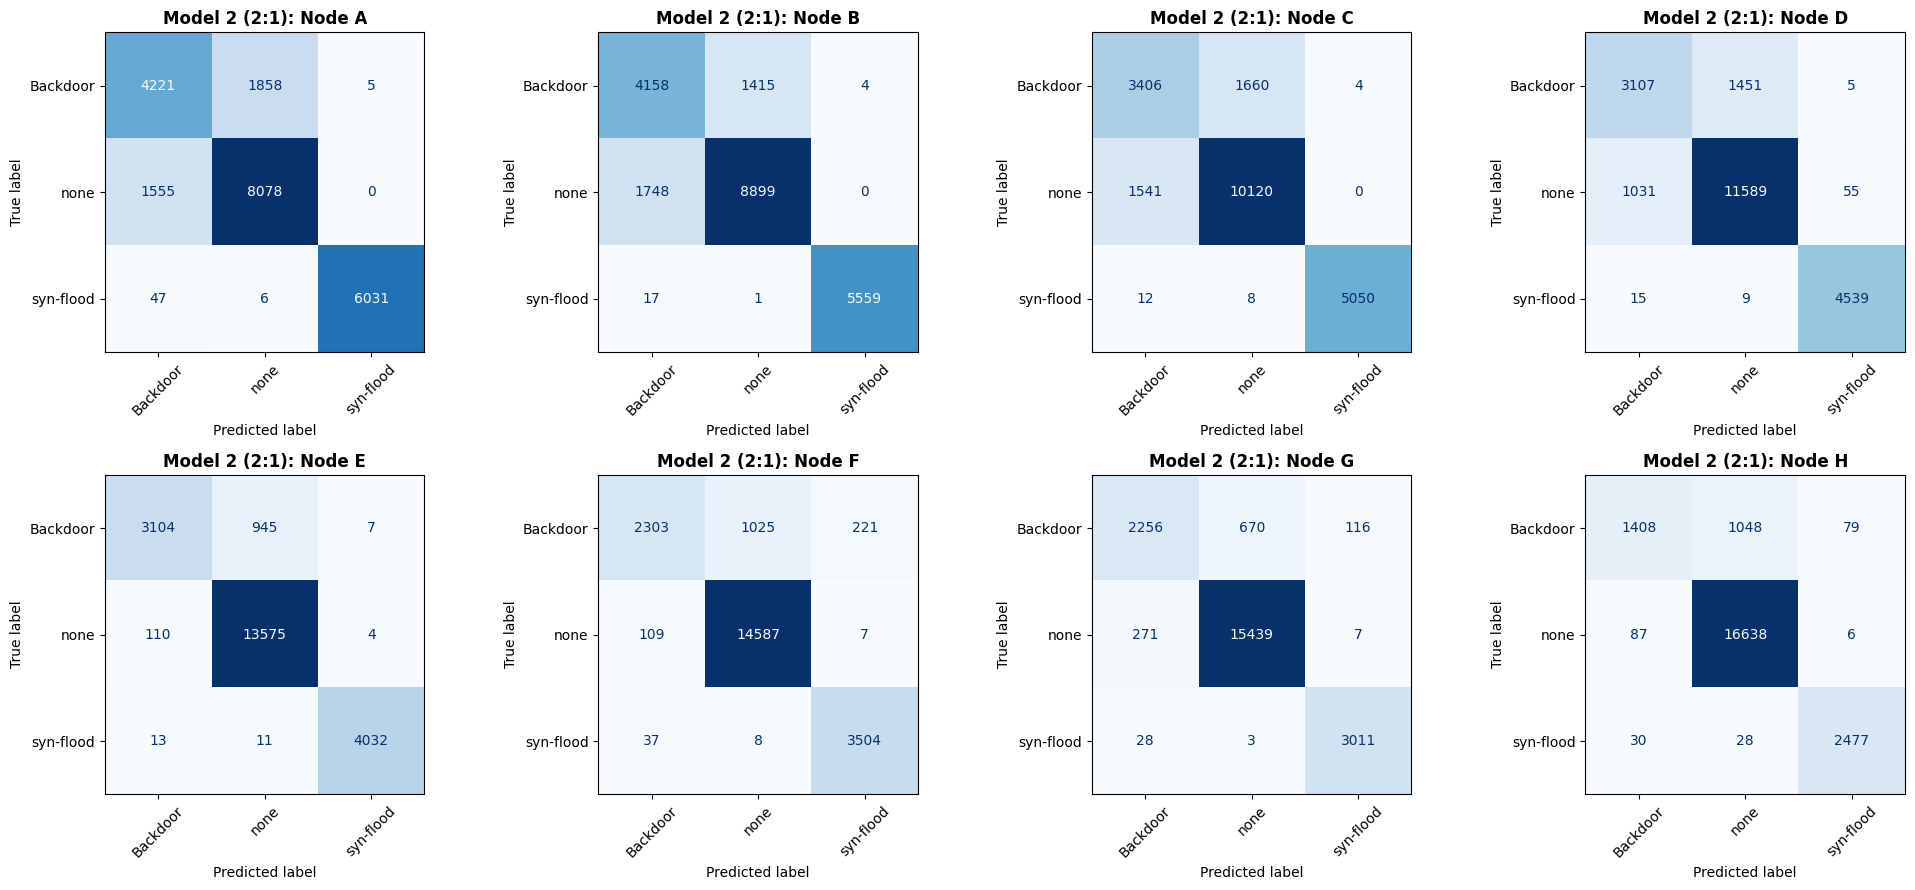

In [71]:
# Cell 7
# =============================================================================
# Model 2: Full Context RF (Own HW & Probs [2x] + Agg Context [1x]) [NO STATE]
# =============================================================================

import os
import joblib
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    ConfusionMatrixDisplay,
    accuracy_score,
    confusion_matrix,
    f1_score,
    log_loss,
    mean_squared_error,
    roc_auc_score,
)
from sklearn.preprocessing import StandardScaler

MODELS_DIR = "models"
os.makedirs(MODELS_DIR, exist_ok=True)

metrics_records_m2 = []
cm_dict_m2 = {}
classes_dict_m2 = {}
all_classes = le.classes_
num_classes = len(all_classes)
labels_arr = np.arange(num_classes)

# Containers to aggregate all node predictions for exact global metrics
all_y_true = []
all_y_pred = []
all_prob_m2 = []

for node in NODES:
    train_df = aug_train[node].copy()
    test_df = aug_test[node].copy()

    # Use global label encoder for uniform class mapping
    y_train = le.transform(train_df["Attack"])
    y_test = le.transform(test_df["Attack"])
    classes_dict_m2[node] = all_classes

    # -------------------------------------------------------------------------
    # 1. Identify Own Features vs. Neighbor-Aggregated Features & Enforce 2:1 Duplication
    # -------------------------------------------------------------------------
    own_cols = [c for c in feature_cols_full if not c.startswith("agg_")]
    agg_cols = [c for c in feature_cols_full if c.startswith("agg_")]

    X_train = train_df[feature_cols_full].copy()
    X_test  = test_df[feature_cols_full].copy()

    # Duplicate own features for 2:1 sampling weight in RF
    for col in own_cols:
        X_train[f"{col}_w2"] = X_train[col]
        X_test[f"{col}_w2"]  = X_test[col]

    # Standardize numeric sensor features
    numeric_own = [c for c in own_cols if c in original_numeric]
    numeric_all = numeric_own + [f"{c}_w2" for c in numeric_own] + agg_numeric

    scaler_full_w = StandardScaler()
    X_train[numeric_all] = scaler_full_w.fit_transform(X_train[numeric_all])
    X_test[numeric_all]  = scaler_full_w.transform(X_test[numeric_all])

    # -------------------------------------------------------------------------
    # 2. Train Random Forest Classifier
    # -------------------------------------------------------------------------
    rf_context_full_w = RandomForestClassifier(
        n_estimators=100,
        random_state=42,
        oob_score=True,
        n_jobs=-1
    )
    rf_context_full_w.fit(X_train.to_numpy(), y_train)

    prob_m2 = rf_context_full_w.predict_proba(X_test.to_numpy())
    pred_m2 = np.argmax(prob_m2, axis=1)

    # Accumulate arrays for global benchmarking
    all_y_true.append(y_test)
    all_y_pred.append(pred_m2)
    all_prob_m2.append(prob_m2)

    # -------------------------------------------------------------------------
    # 3. Compute Per-Node Metrics
    # -------------------------------------------------------------------------
    macro_f1 = f1_score(y_test, pred_m2, average="macro")
    mse_error = mean_squared_error(y_test, pred_m2)
    loss = log_loss(y_test, prob_m2, labels=labels_arr)

    try:
        roc_auc = roc_auc_score(
            y_test,
            prob_m2,
            multi_class="ovr",
            average="macro",
            labels=labels_arr,
        )
    except ValueError:
        roc_auc = np.nan

    cm = confusion_matrix(y_test, pred_m2, labels=labels_arr)
    cm_dict_m2[node] = cm

    metrics_records_m2.append({
        "Node": f"Node {node}",
        "Samples": len(test_df),
        "Macro F1": macro_f1,
        "MSE": mse_error,
        "Log Loss": loss,
        "ROC-AUC": roc_auc,
    })

    print(f"=== Model 2 (2:1 Weighted): Node {node} (Samples: {len(test_df)}) ===")
    print(f"  OOB Score:             {rf_context_full_w.oob_score_:.6f}")
    print(f"  Macro F1-Score:        {macro_f1:.6f}")
    print(f"  Mean Squared Error:    {mse_error:.6f}")
    print(f"  Log Loss:              {loss:.6f}")
    print(f"  ROC-AUC Score:         {roc_auc:.6f}")
    print("  Confusion Matrix (Rows: True, Cols: Predicted):")
    print(f"  Classes: {all_classes}")
    print(f"  {cm.tolist()}\n")

    # -------------------------------------------------------------------------
    # 4. Save Artifacts & Predictions
    # -------------------------------------------------------------------------
    model_path = os.path.join(MODELS_DIR, f"Node_{node}_rf_context_full_w2.joblib")
    scaler_path = os.path.join(MODELS_DIR, f"Node_{node}_scaler_context_full_w2.joblib")
    encoder_path = os.path.join(MODELS_DIR, f"Node_{node}_label_encoder_context_full_w2.joblib")
    feature_list_path = os.path.join(MODELS_DIR, f"Node_{node}_feature_list_context_full_w2.csv")
    predictions_path = os.path.join(MODELS_DIR, f"Node_{node}_predictions_test_rf_context_full_w2.csv")

    joblib.dump(rf_context_full_w, model_path)
    joblib.dump(scaler_full_w, scaler_path)
    joblib.dump(le, encoder_path)
    pd.DataFrame({"feature": X_train.columns.tolist()}).to_csv(feature_list_path, index=False)

    df_pred_full = test_df[["Attack"]].copy()
    df_pred_full["prediction"] = le.inverse_transform(pred_m2)
    for idx, cls_idx in enumerate(rf_context_full_w.classes_):
        cls_name = le.inverse_transform([cls_idx])[0]
        df_pred_full[f"prob_{cls_name}"] = prob_m2[:, idx]
    df_pred_full.to_csv(predictions_path, index=False)

# =============================================================================
# Summary DataFrame and Exact Global Metrics Across All Pooled Nodes
# =============================================================================
df_summary_m2 = pd.DataFrame(metrics_records_m2)
print("=============================================================================")
print("PER-NODE SUMMARY (MODEL 2 - NO STATE, 2:1 WEIGHTED):")
print(df_summary_m2.to_string(index=False))

# Concatenate all true labels, predicted classes, and probabilities
y_true_all = np.concatenate(all_y_true)
y_pred_all = np.concatenate(all_y_pred)
y_prob_all = np.concatenate(all_prob_m2, axis=0)

global_acc = accuracy_score(y_true_all, y_pred_all)
global_macro_f1 = f1_score(y_true_all, y_pred_all, average="macro")
global_weighted_f1 = f1_score(y_true_all, y_pred_all, average="weighted")
global_mse = mean_squared_error(y_true_all, y_pred_all)
global_loss = log_loss(y_true_all, y_prob_all, labels=labels_arr)

try:
    global_roc_auc = roc_auc_score(
        y_true_all, y_prob_all, multi_class="ovr", average="macro", labels=labels_arr
    )
except ValueError:
    global_roc_auc = np.nan

print("\n=== Global Benchmarking Metrics (All Nodes Pooled) ===")
print(f"  Accuracy:              {global_acc:.6f}")
print(f"  Macro F1:              {global_macro_f1:.6f}")
print(f"  Weighted F1:           {global_weighted_f1:.6f}")
print(f"  MSE:                   {global_mse:.6f}")
print(f"  Log Loss:              {global_loss:.6f}")
print(f"  ROC-AUC (Macro OVR):   {global_roc_auc:.6f}")
print("=============================================================================\n")

# -----------------------------------------------------------------------------
# Plot Confusion Matrices for All Nodes
# -----------------------------------------------------------------------------
n_nodes = len(NODES)
cols = 4
rows = (n_nodes + cols - 1) // cols

fig, axes = plt.subplots(rows, cols, figsize=(5 * cols, 4.5 * rows))
axes = np.array(axes).reshape(-1)

for idx, node in enumerate(NODES):
    ax = axes[idx]
    disp = ConfusionMatrixDisplay(
        confusion_matrix=cm_dict_m2[node],
        display_labels=classes_dict_m2[node],
    )
    disp.plot(ax=ax, cmap="Blues", colorbar=False, values_format="d")
    ax.set_title(f"Model 2 (2:1): Node {node}", fontsize=12, fontweight="bold")
    ax.tick_params(axis="x", rotation=45)

for idx in range(n_nodes, len(axes)):
    fig.delaxes(axes[idx])

plt.tight_layout()
plt.show()

Creating feature-importance plot for Node A...


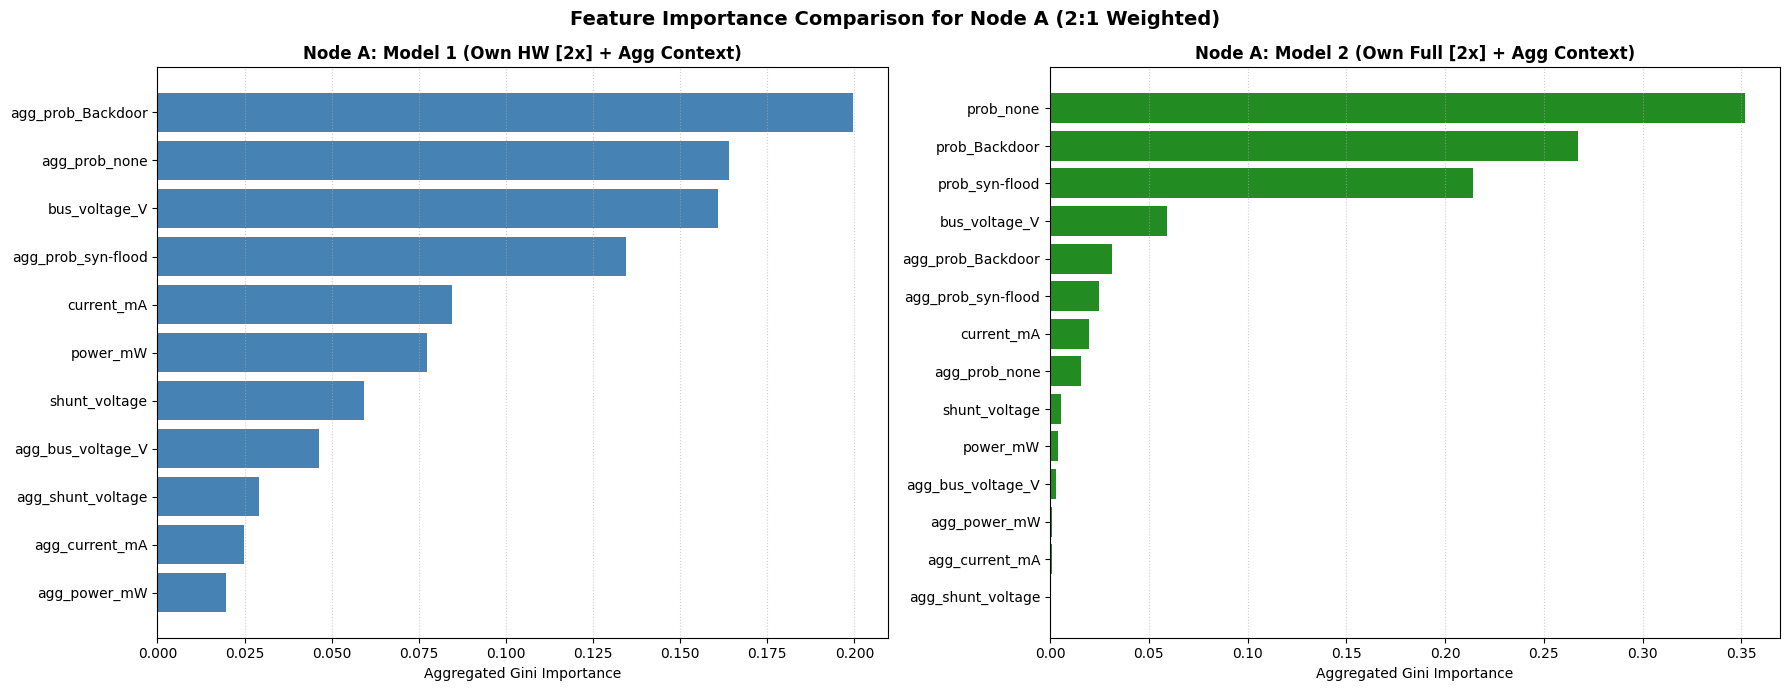

Creating feature-importance plot for Node B...


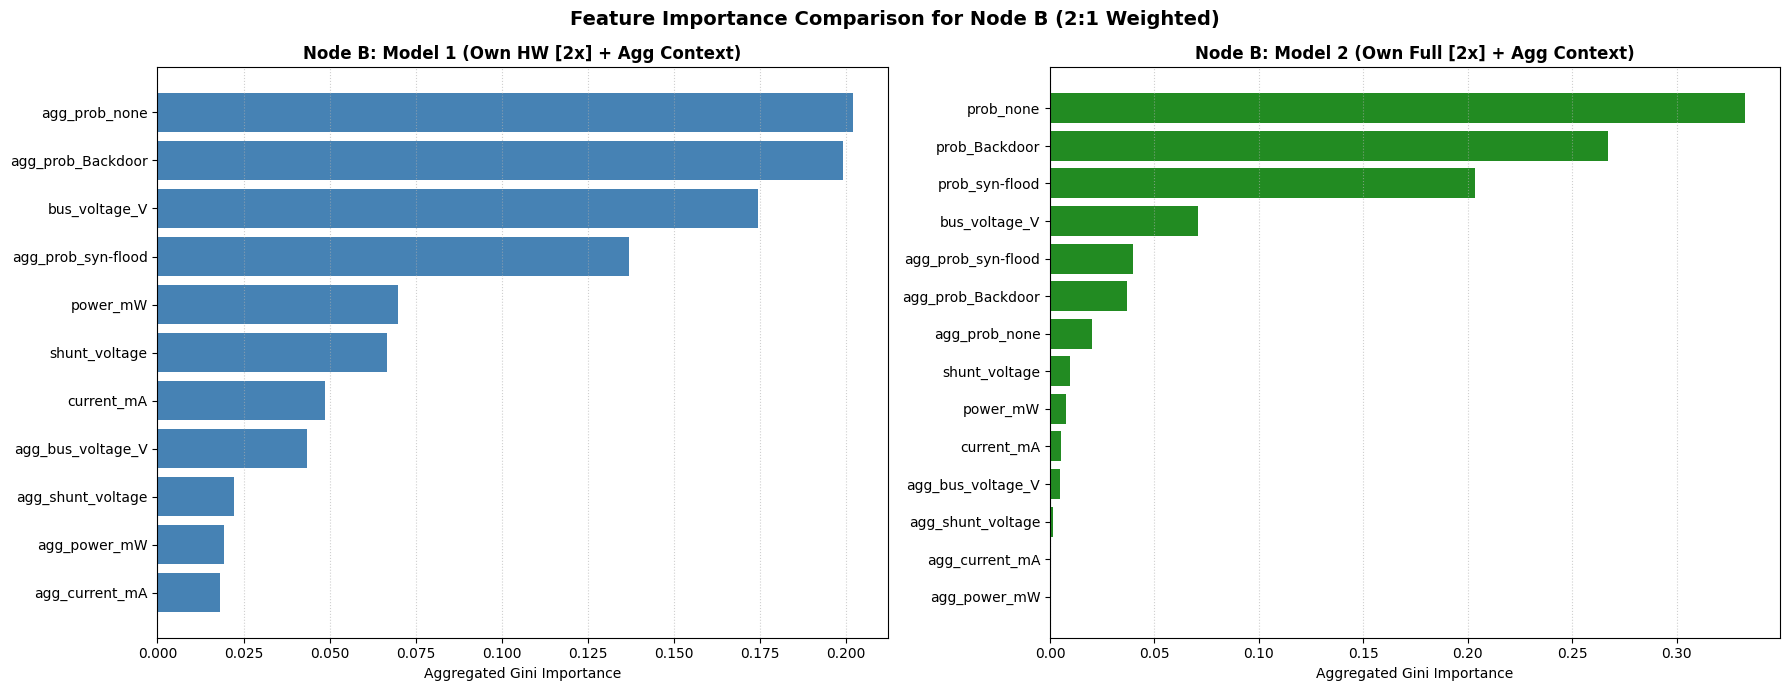

Creating feature-importance plot for Node C...


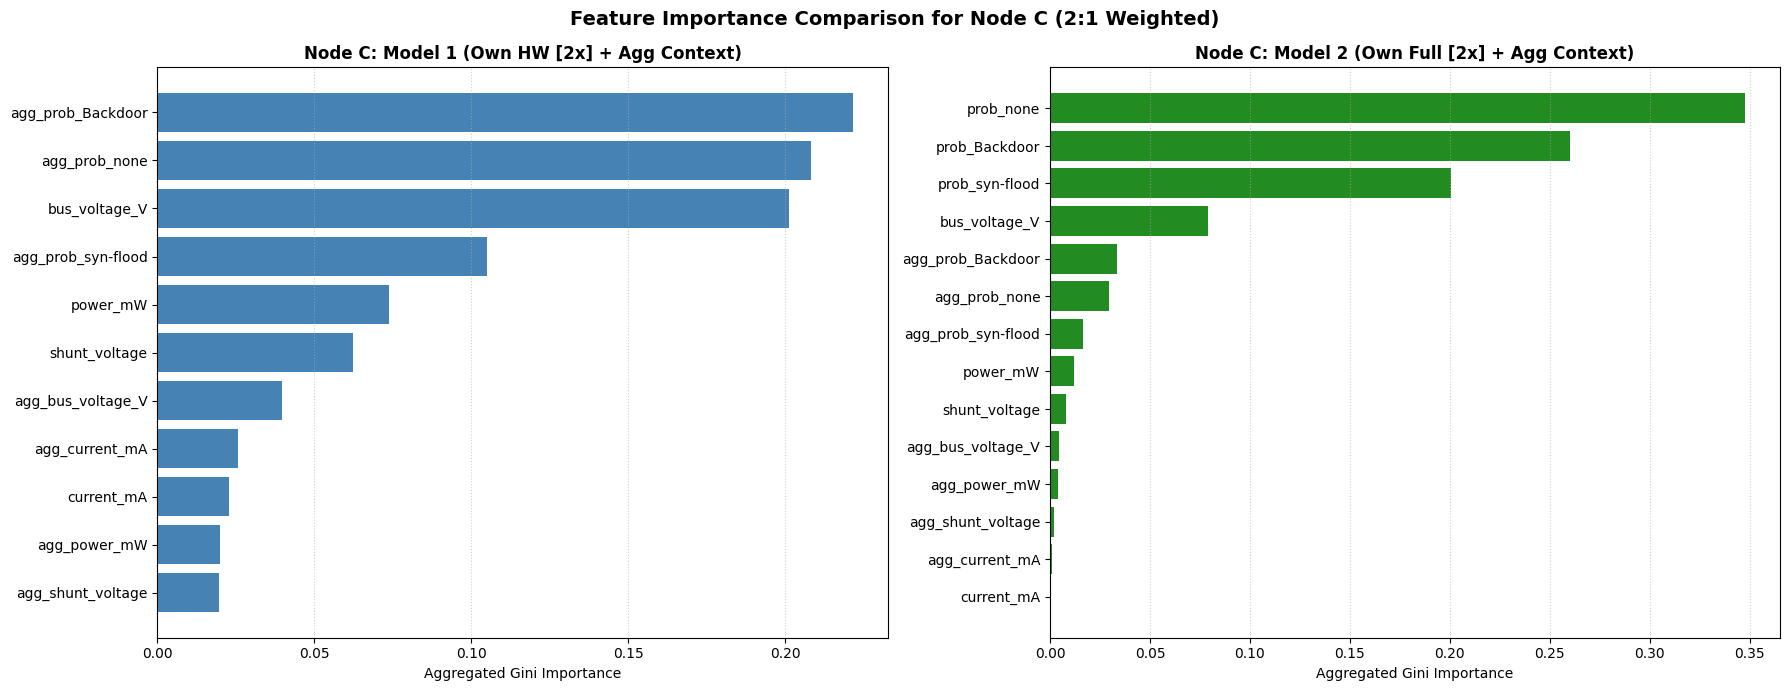

Creating feature-importance plot for Node D...


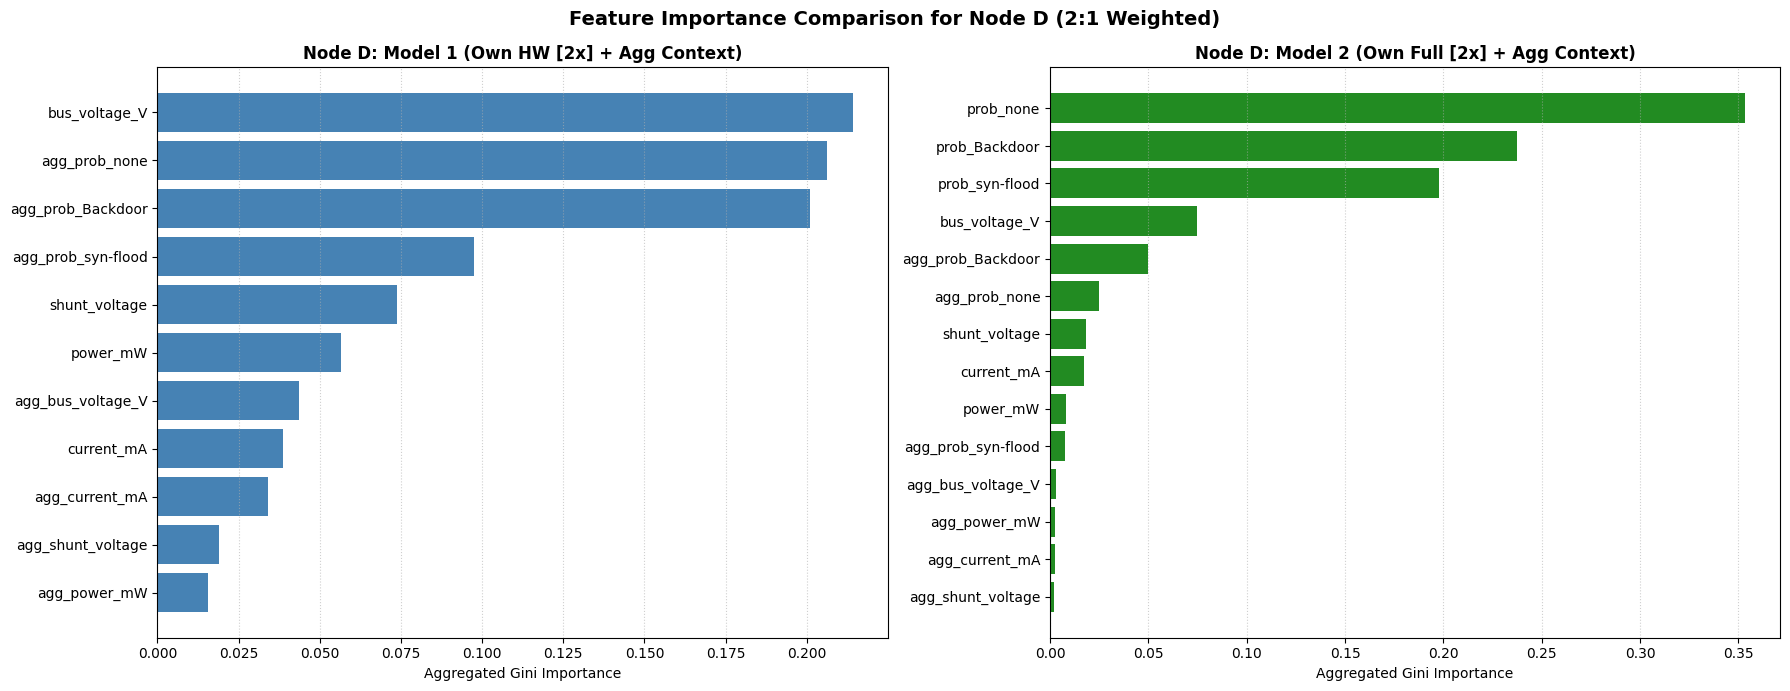

Creating feature-importance plot for Node E...


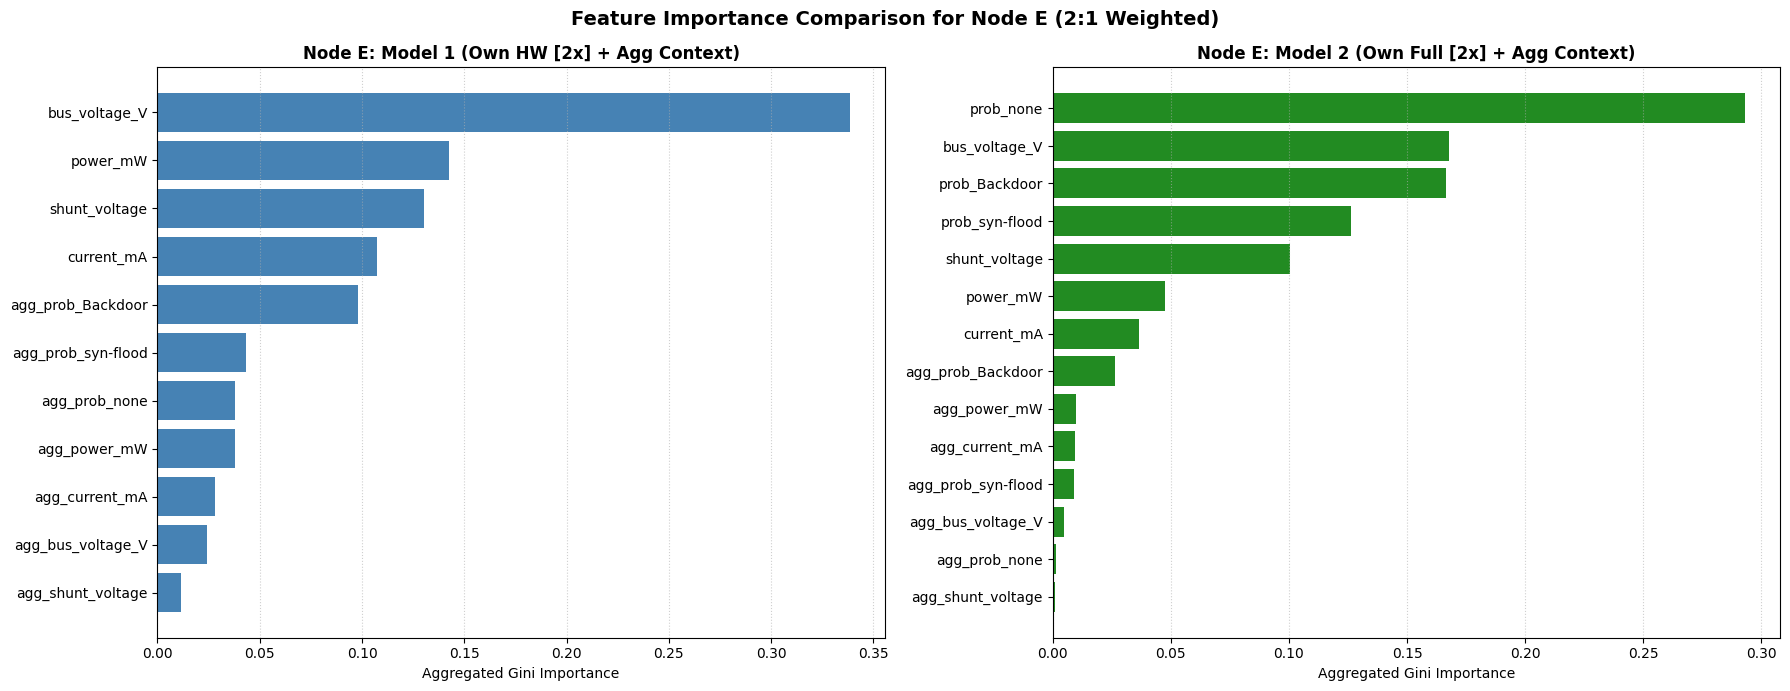

Creating feature-importance plot for Node F...


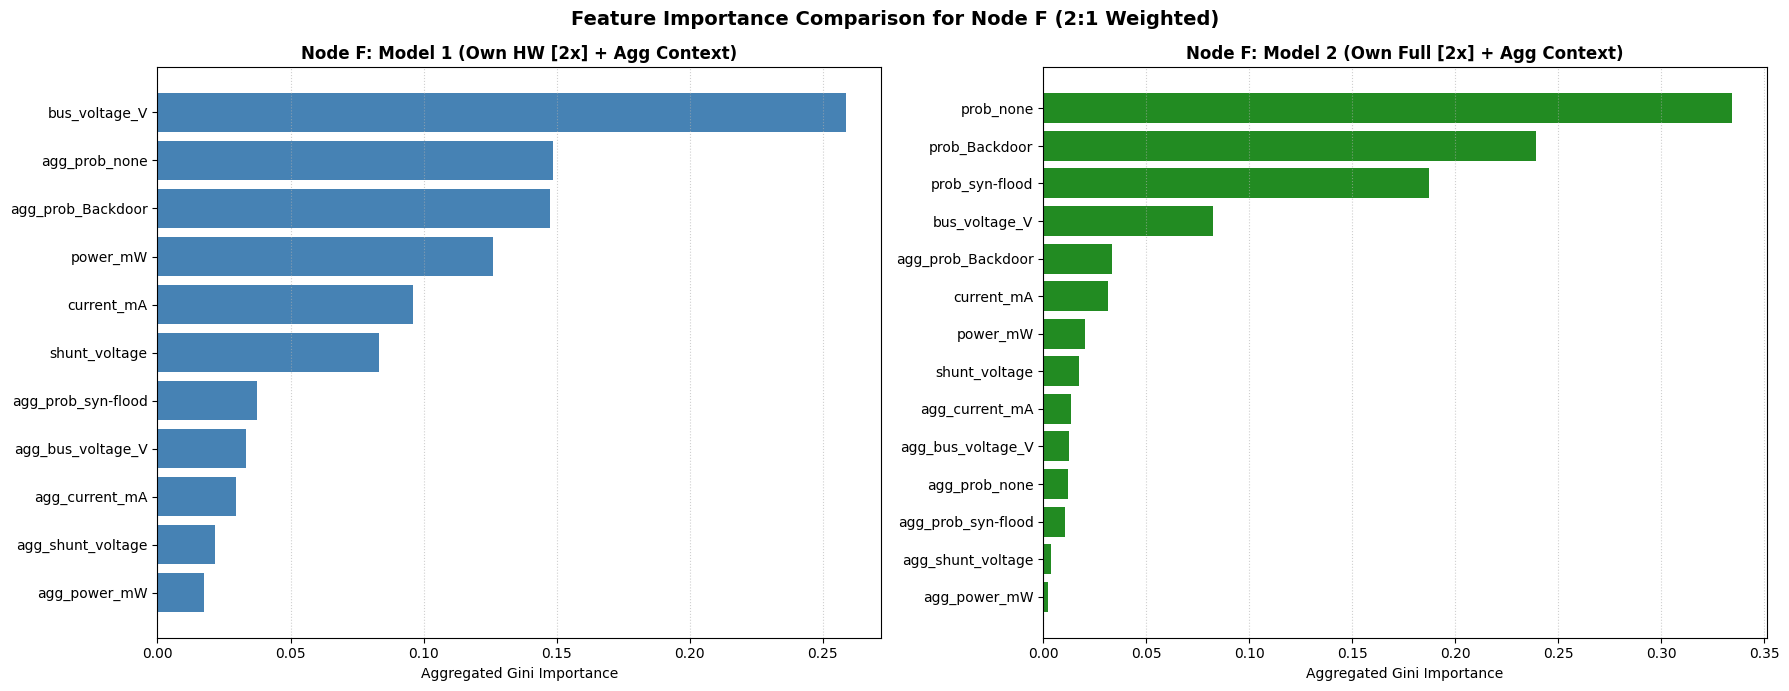

Creating feature-importance plot for Node G...


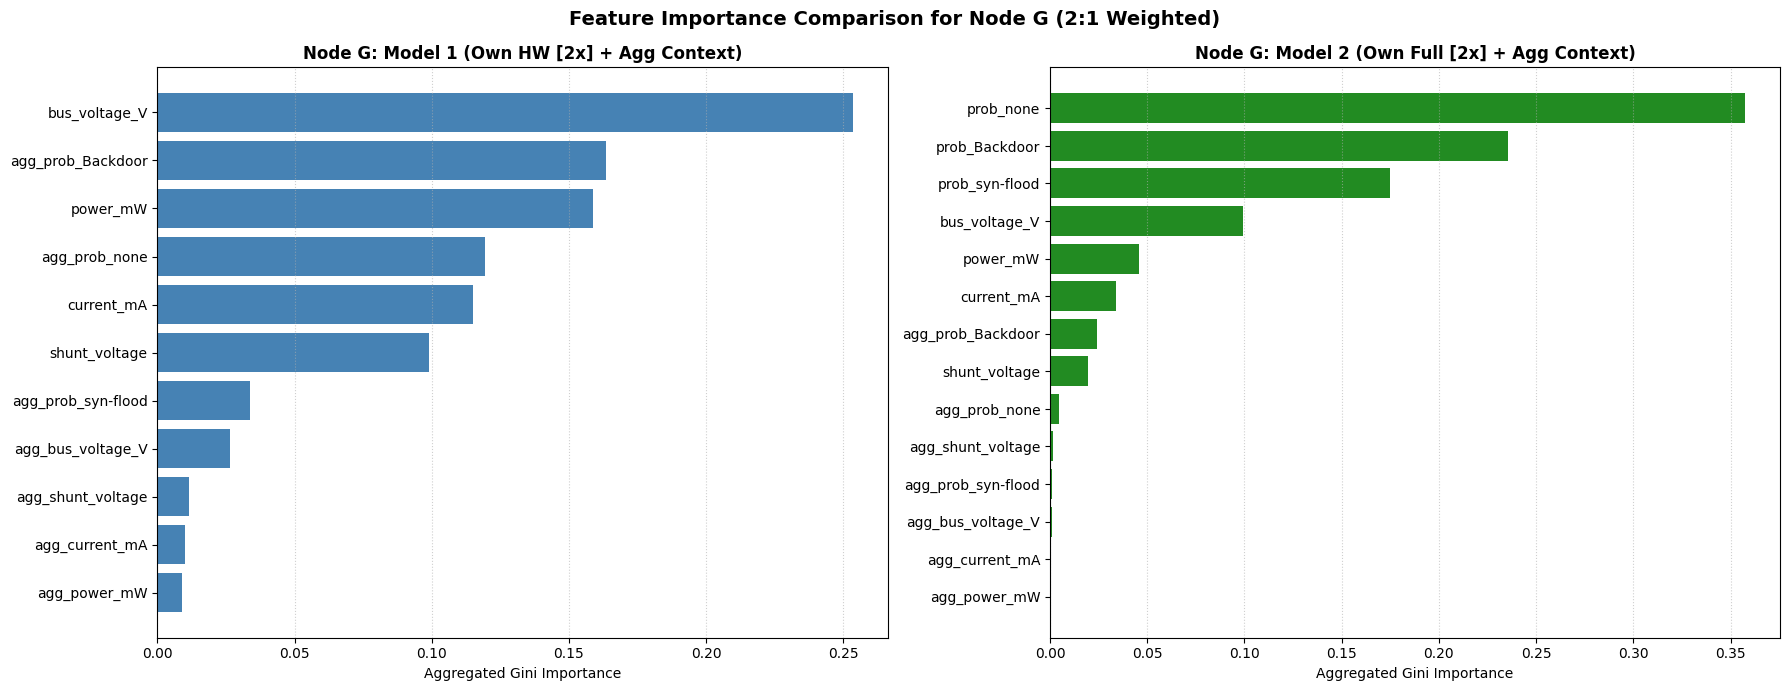

Creating feature-importance plot for Node H...


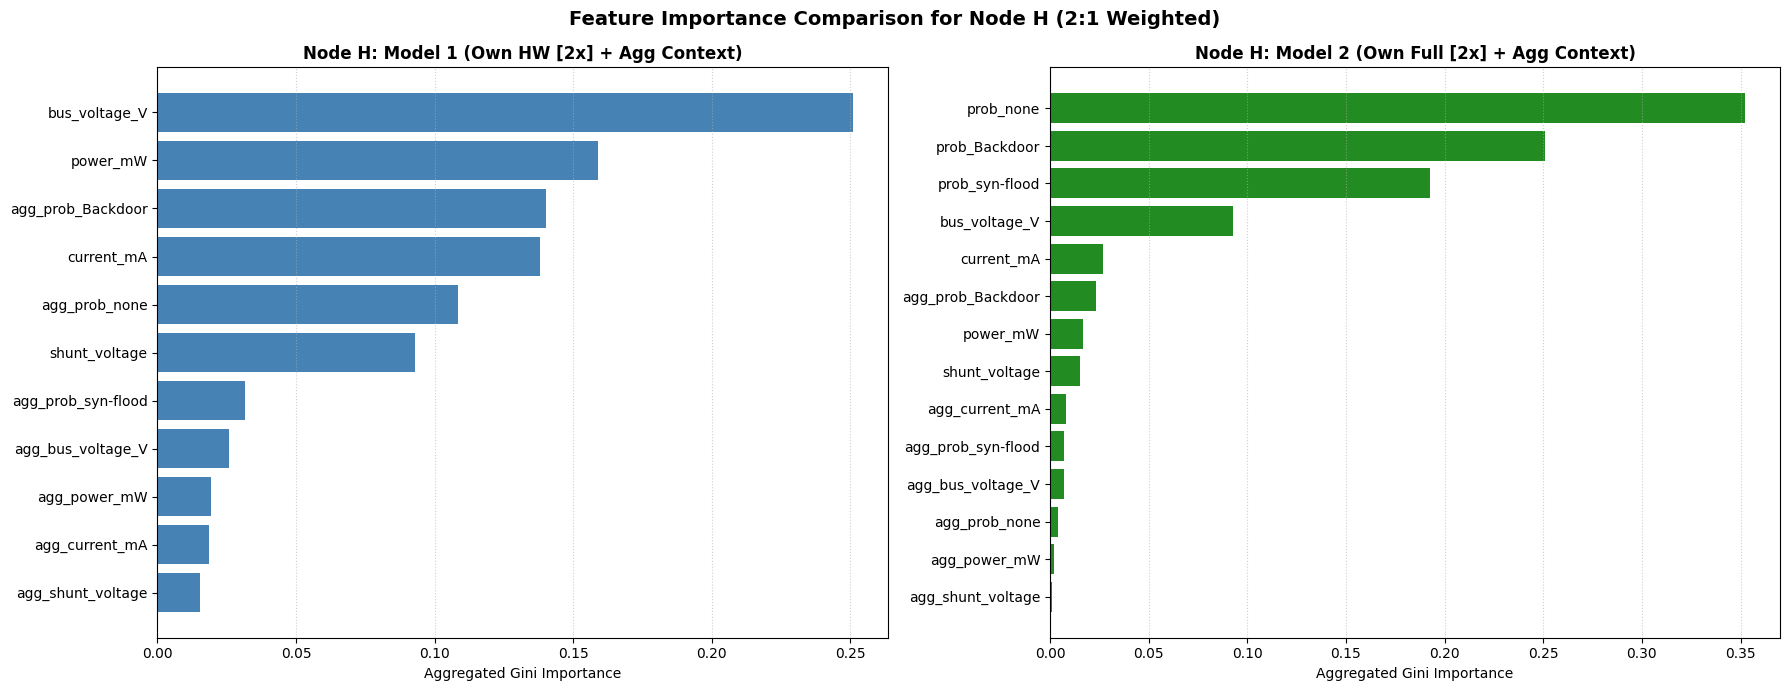

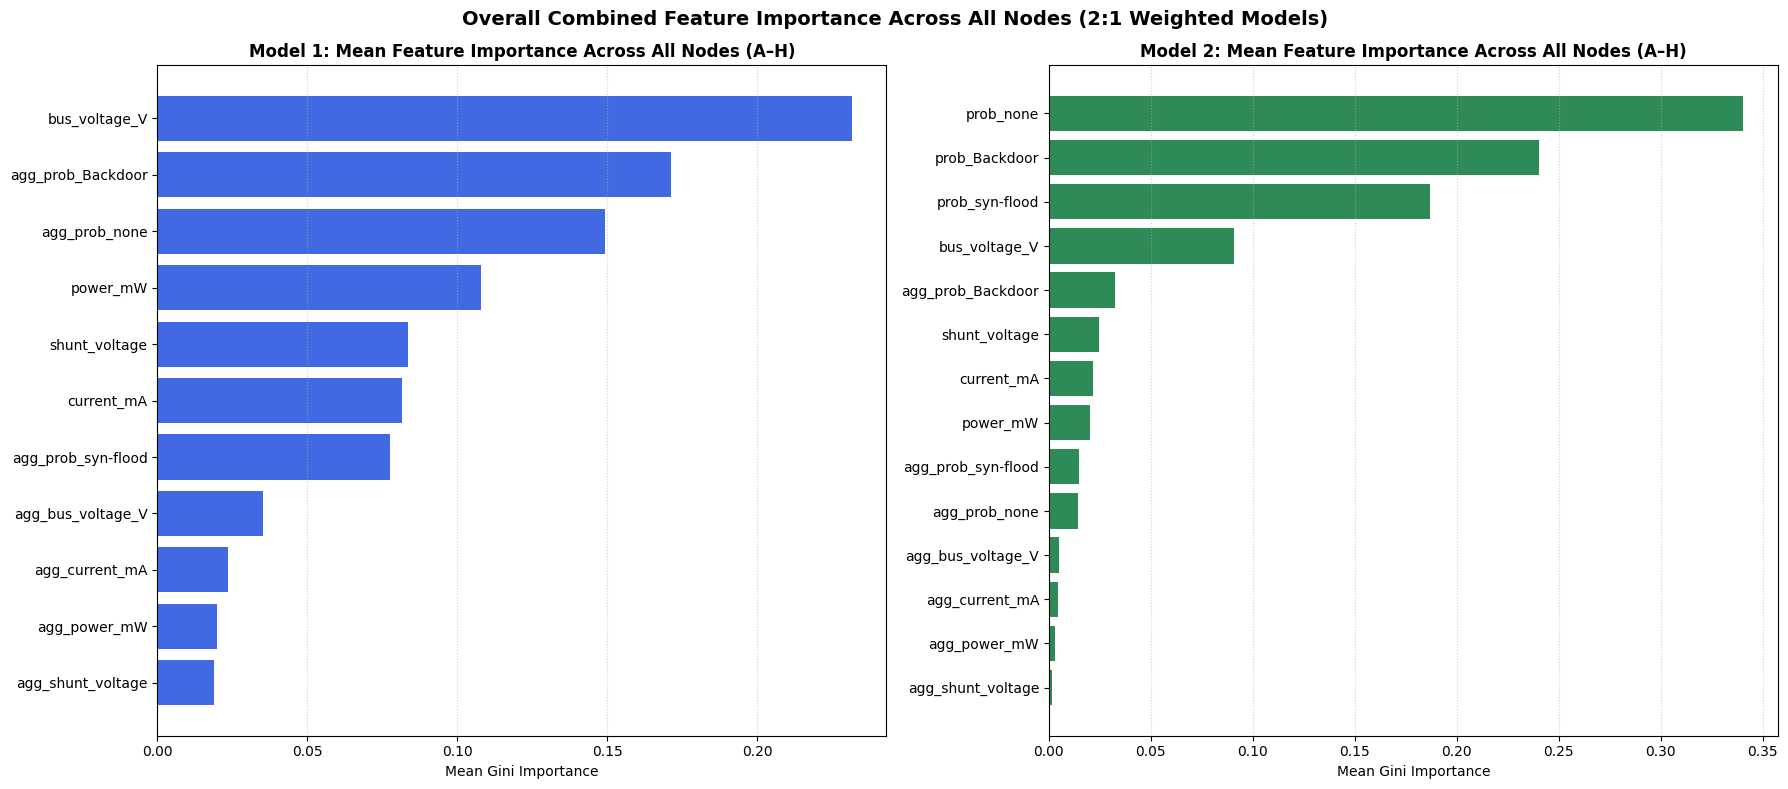


All node plots and global summary saved to 'models/feature_importance_plots/'


In [72]:
# Cell 8
# =============================================================================
# Plot Feature Importance Per Node & Overall Across All Nodes (2:1 Weighted)
# =============================================================================

import os
import joblib
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

MODELS_DIR = "models"
PLOTS_DIR = os.path.join(MODELS_DIR, "feature_importance_plots")
os.makedirs(PLOTS_DIR, exist_ok=True)

all_node_imp1 = []
all_node_imp2 = []

# -----------------------------------------------------------------------------
# 1. Generate & Save Per-Node Feature Importance Plots
# -----------------------------------------------------------------------------
for node in NODES:
    print(f"Creating feature-importance plot for Node {node}...")

    # Load 2:1 weighted models
    rf_hw_agg = joblib.load(
        os.path.join(MODELS_DIR, f"Node_{node}_rf_context_own_hw_plus_agg_w2.joblib")
    )
    rf_full = joblib.load(
        os.path.join(MODELS_DIR, f"Node_{node}_rf_context_full_w2.joblib")
    )

    # Load feature lists
    feat_hw_agg = pd.read_csv(
        os.path.join(MODELS_DIR, f"Node_{node}_feature_list_own_hw_plus_agg_w2.csv")
    )["feature"].tolist()

    feat_full = pd.read_csv(
        os.path.join(MODELS_DIR, f"Node_{node}_feature_list_context_full_w2.csv")
    )["feature"].tolist()

    # Aggregate importance by stripping '_w2' and summing duplicates
    df_imp1_raw = pd.DataFrame({
        "Feature": [f.replace("_w2", "") for f in feat_hw_agg],
        "Importance": rf_hw_agg.feature_importances_
    })
    df_imp1 = (
        df_imp1_raw.groupby("Feature", as_index=False)
        .sum()
        .sort_values("Importance", ascending=True)
    )

    df_imp2_raw = pd.DataFrame({
        "Feature": [f.replace("_w2", "") for f in feat_full],
        "Importance": rf_full.feature_importances_
    })
    df_imp2 = (
        df_imp2_raw.groupby("Feature", as_index=False)
        .sum()
        .sort_values("Importance", ascending=True)
    )

    # Collect for overall global average
    all_node_imp1.append(df_imp1.assign(Node=node))
    all_node_imp2.append(df_imp2.assign(Node=node))

    # Plot comparison for single node
    fig, axes = plt.subplots(1, 2, figsize=(18, 7))

    axes[0].barh(df_imp1["Feature"], df_imp1["Importance"], color="steelblue")
    axes[0].set_title(f"Node {node}: Model 1 (Own HW [2x] + Agg Context)", fontweight="bold")
    axes[0].set_xlabel("Aggregated Gini Importance")
    axes[0].grid(True, axis="x", linestyle=":", alpha=0.6)

    axes[1].barh(df_imp2["Feature"], df_imp2["Importance"], color="forestgreen")
    axes[1].set_title(f"Node {node}: Model 2 (Own Full [2x] + Agg Context)", fontweight="bold")
    axes[1].set_xlabel("Aggregated Gini Importance")
    axes[1].grid(True, axis="x", linestyle=":", alpha=0.6)

    fig.suptitle(f"Feature Importance Comparison for Node {node} (2:1 Weighted)", fontsize=14, fontweight="bold")
    plt.tight_layout()

    plot_path = os.path.join(PLOTS_DIR, f"Node_{node}_feature_importance_comparison_w2.png")
    plt.savefig(plot_path, dpi=300, bbox_inches="tight")
    plt.show()
    plt.close(fig)

# -----------------------------------------------------------------------------
# 2. Compute & Plot Combined Average Feature Importance Across All Nodes
# -----------------------------------------------------------------------------
df_global_imp1 = (
    pd.concat(all_node_imp1, ignore_index=True)
    .groupby("Feature", as_index=False)["Importance"]
    .mean()
    .sort_values("Importance", ascending=True)
)

df_global_imp2 = (
    pd.concat(all_node_imp2, ignore_index=True)
    .groupby("Feature", as_index=False)["Importance"]
    .mean()
    .sort_values("Importance", ascending=True)
)

fig_global, axes_global = plt.subplots(1, 2, figsize=(18, 8))

# Model 1 Global Average
axes_global[0].barh(df_global_imp1["Feature"], df_global_imp1["Importance"], color="royalblue")
axes_global[0].set_title("Model 1: Mean Feature Importance Across All Nodes (A–H)", fontsize=12, fontweight="bold")
axes_global[0].set_xlabel("Mean Gini Importance")
axes_global[0].grid(True, axis="x", linestyle=":", alpha=0.6)

# Model 2 Global Average
axes_global[1].barh(df_global_imp2["Feature"], df_global_imp2["Importance"], color="seagreen")
axes_global[1].set_title("Model 2: Mean Feature Importance Across All Nodes (A–H)", fontsize=12, fontweight="bold")
axes_global[1].set_xlabel("Mean Gini Importance")
axes_global[1].grid(True, axis="x", linestyle=":", alpha=0.6)

fig_global.suptitle("Overall Combined Feature Importance Across All Nodes (2:1 Weighted Models)", fontsize=14, fontweight="bold")
plt.tight_layout()

global_plot_path = os.path.join(PLOTS_DIR, "All_Nodes_Combined_feature_importance_w2.png")
plt.savefig(global_plot_path, dpi=300, bbox_inches="tight")
plt.show()
plt.close(fig_global)

print(f"\nAll node plots and global summary saved to '{PLOTS_DIR}/'")